In [3]:
import os, sys
sys.path.insert(0, '..')

import glob
import joblib
from collections import defaultdict
from itertools import product

import pandas as pd
from tqdm import tqdm

from src.data.io import read_df, write_df
from src.data.utils import round_to_significant
from src.ml.evaluate import inner_score
from src.analysis.aggregate import scores_to_df, study_to_df
from src.analysis.stats import *

/Users/miwan/miniforge3/envs/carbide/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Demographic Missingness

In [59]:
dfs = []
for file in glob.glob("../data/raw/*"):
    df = read_df(file)[['sex', 'age_months', 'weight_kg']]
    dfs.append(df)

df = pd.concat(dfs)
del dfs

In [81]:
import numpy as np
print(f"Missing information on Sex: {np.round(df['sex'].isna().sum()/len(df)*100, 2):.2f}%")
print(f"Missing information on Age: {np.round(df['age_months'].isna().sum()/len(df)*100, 2):.2f}%")
print(f"Missing information on Weight: {np.round(df['weight_kg'].isna().sum()/len(df)*100, 2):.2f}%")

Missing information on Sex: 12.80%
Missing information on Age: 42.83%
Missing information on Weight: 81.20%


In [84]:
# For Sex, no changes
# For Age, we encoded entries outside the [0, 1200] interval as "Unknown"
# For Weight, we encoded entries outside the (0.05, 0.95) quantiles as "Unknown", if Age was known OR outside the (0.10, 0.90) if it was not known

In [73]:
age_df = df[['age_months']].dropna().reset_index().astype({'age_months': 'float'})

In [78]:
print(f"Percent implausible Age: {np.round(100 - 100 * len(age_df[(age_df['age_months'] > 0.0) & (age_df['age_months'] < 1200.0)]) / len(age_df), 2)}%")

Percent implausible Age: 0.19%


In [82]:
wgt_df = df.dropna(subset='weight_kg').reset_index(drop=True)

In [87]:
wgt_age_known = wgt_df[~wgt_df['age_months'].isna()]
wgt_age_not_known = wgt_df[wgt_df['age_months'].isna()]

In [89]:
age_known_removed = 0.1 * len(wgt_age_known)
age_unknown_removed = 0.2 * len(wgt_age_not_known)

In [91]:
print(f"Percentile implausible Weight: {100*(age_known_removed + age_unknown_removed)/len(wgt_df):.2f}%")

Percentile implausible Weight: 11.75%


### Label distribution across folds

In [104]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from src.visualise.plot import two_point_palette

In [101]:
df = read_df('../data/carbide/primary/Cred/carbide_prr.joblib')[['Label', 'Fold']]

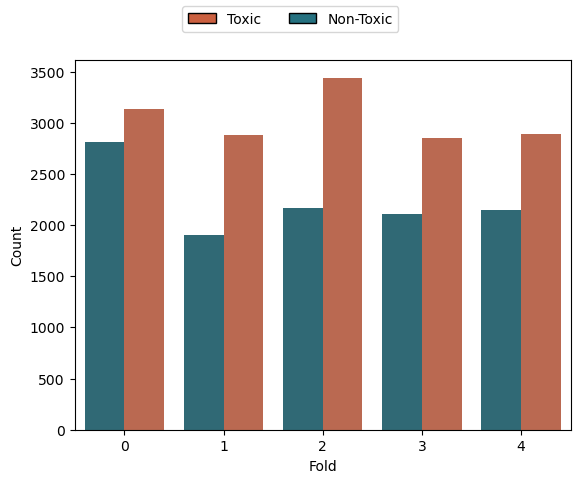

In [113]:
tpp = two_point_palette()
g = sns.countplot(data=df, x='Fold', hue='Label', legend=False, palette=tpp)
plt.ylabel('Count')
labels = ['Toxic', 'Non-Toxic']
handles = [Patch(edgecolor='black', facecolor=col) for col in tpp[::-1]]
g.figure.legend(labels=labels, handles=handles, loc='upper center', ncol=2)


In [ ]:
cts = df.groupby('Fold').value_counts().reset_index()

In [124]:
cts.groupby('Label').apply(lambda group: np.round(group['count'].std() / group['count'].mean() * 100, 2))

/tmp/ipykernel_3796889/1121624919.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cts.groupby('Label').apply(lambda group: np.round(group['count'].std() / group['count'].mean() * 100, 2))


Label
0    15.36
1     8.31
dtype: float64

### Aggregate and process results from model training

In [ ]:
"""
Aggregated results (aggregated.tar.gz) are provided in the same directory as raw dataset
and can be unpacked using:
tar -xvf aggregated.tar.gz
"""

In [9]:
global_dir = '../results/training'

In [3]:
# Combine files made for each fold

ddc = defaultdict(int)

for file in tqdm(glob.glob(f'{global_dir}/*/*/*/*.joblib'), total=1620*4):
    _, _, _, dataset_pt_dpa, model, descriptors, file_name = file.split('/')

    if 'ensemble' in file_name:
        continue

    dataset, pt, dpa = dataset_pt_dpa.split('_')
    _, _, test_fold = file_name.rstrip('.joblib').split('_')
    df = read_df(file)

    if 'preds' in file_name:
        df['Signature'] = df['Signature'].apply(lambda sign: ' | '.join(sign))
        df['Test_Fold'] = test_fold
        out_path = file.replace('.joblib', '.tsv')
        write_df(df, out_path)

    elif 'scores' in file_name:
        df = scores_to_df(df)
        df['Test_Fold'] = test_fold
        out_path = file.replace('.joblib', '.tsv')
        write_df(df, out_path)

    elif 'study' in file_name:
        df = study_to_df(df)
        df['Test_Fold'] = test_fold
        df['Model'] = model
        df['Descriptors'] = descriptors
        out_path = file.replace('.joblib', '.tsv')
        write_df(df, out_path)

    else:
        raise ValueError('File not found, please check your code :c')

  5%|▌         | 243/4860 [00:04<01:22, 55.74it/s]/wuppertal/gptil/Repos/PMD/src/analysis/aggregate.py:68: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  study_df = pd.concat(trial_dfs).reset_index(drop=True)
  5%|▌         | 267/4860 [00:04<01:25, 53.61it/s]/wuppertal/gptil/Repos/PMD/src/analysis/aggregate.py:68: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  study_df = pd.concat(trial_dfs).reset_index(drop=True)
 13%|█▎        | 609/4860 [00:11<01:17, 54.72it/s]/wuppertal/gptil/Repos/PMD/src/ana

In [4]:
# Combine scores into single file on a per dataset_variant-model-descriptor basis

ddc_scores = defaultdict(list)

for file in tqdm(glob.glob('../results/training/*/*/*/scores*.tsv'), total=1620):
    _, _, _, dataset_pt_dpa, model, descriptors, file_name = file.split('/')
    dataset, pt, dpa = dataset_pt_dpa.split('_')
    _, _, test_fold = file_name.rstrip('.tsv').split('_')
    df = read_df(file)
    key = (dataset, pt, dpa, model, descriptors)
    ddc_scores[key].append(df)

for (dataset, pt, dpa, model, descriptors), values in ddc_scores.items():
    os.makedirs(f'../results/aggregated/{dataset}_{pt}_{dpa}/', exist_ok=True)
    out_path = f'../results/aggregated/{dataset}_{pt}_{dpa}/{model}_{descriptors}_scores.tsv'
    df = pd.concat(values).reset_index(drop=True)
    df['Model'] = model
    df['Descriptors'] = descriptors
    write_df(df, out_path)

100%|██████████| 1620/1620 [00:01<00:00, 817.49it/s]


In [5]:
# Combine studies into single file on a per dataset_variant-model-descriptor basis

ddc_scores = defaultdict(list)

for file in tqdm(glob.glob('../results/training/*/*/*/study*.tsv'), total=1620):
    _, _, _, dataset_pt_dpa, model, descriptors, file_name = file.split('/')
    dataset, pt, dpa = dataset_pt_dpa.split('_')
    _, _, test_fold = file_name.rstrip('.tsv').split('_')
    df = read_df(file)
    key = (dataset, pt, dpa, model, descriptors)
    ddc_scores[key].append(df)

for (dataset, pt, dpa, model, descriptors), values in ddc_scores.items():
    os.makedirs(f'../results/aggregated/{dataset}_{pt}_{dpa}/', exist_ok=True)
    out_path = f'../results/aggregated/{dataset}_{pt}_{dpa}/{model}_{descriptors}_studies.tsv'
    df = pd.concat(values).reset_index(drop=True)
    write_df(df, out_path)

100%|██████████| 1620/1620 [00:02<00:00, 808.08it/s]


In [6]:
# Combine predictions into single file on a per dataset_variant-model-descriptor basis

ddc_scores = defaultdict(list)

for file in tqdm(glob.glob('../results/training/*/*/*/preds*.tsv'), total=1620):
    _, _, _, dataset_pt_dpa, model, descriptors, file_name = file.split('/')
    dataset, pt, dpa = dataset_pt_dpa.split('_')
    _, _, test_fold = file_name.rstrip('.tsv').split('_')
    df = read_df(file)
    key = (dataset, pt, dpa, model, descriptors)
    ddc_scores[key].append(df)

for (dataset, pt, dpa, model, descriptors), values in tqdm(ddc_scores.items(), total=324):
    os.makedirs(f'../results/aggregated/{dataset}_{pt}_{dpa}/', exist_ok=True)
    out_path = f'../results/aggregated/{dataset}_{pt}_{dpa}/{model}_{descriptors}_preds.tsv'
    df = pd.concat(values).reset_index(drop=True)
    df['Model'] = model
    df['Descriptors'] = descriptors
    write_df(df, out_path)

100%|██████████| 324/324 [00:56<00:00,  5.70it/s]


### Evaluate Inclusion Criteria

In [2]:
# Aggregate results by inclusion criteria and score on overlapping parts of corresponding datasets

pts = ["Cred", "Card", "Cvas"]
dpas = ["prr", "ror", "ic"]
models = ["LogisticRegression", "RandomForestClassifier", "XGBClassifier"]
descriptors = ["CDDD", "MACCS", "Klek", "RDKit", "ChemBERTa", "Morgan"]

for pt, dpa, model, desc in tqdm(product(pts, dpas, models, descriptors), total=162):

    mono_path = f'../results/aggregated_review/mono_{pt}_{dpa}/{model}_{desc}_preds.tsv'
    primary_path = f'../results/aggregated_review/primary_{pt}_{dpa}/{model}_{desc}_preds.tsv'
    secondary_path = f'../results/aggregated_review/secondary_{pt}_{dpa}/{model}_{desc}_preds.tsv'

    mono_df = read_df(mono_path)
    primary_df = read_df(primary_path)
    secondary_df = read_df(secondary_path)

    mono_df = mono_df.rename(columns={
        'y_pred': 'y_pred_mono',
        'y_score': 'y_score_mono',
    })

    primary_df = primary_df.rename(columns={
        'y_pred': 'y_pred_primary',
        'y_score': 'y_score_primary',
    })

    secondary_df = secondary_df.rename(columns={
        'y_pred': 'y_pred_secondary',
        'y_score': 'y_score_secondary',
    })

    merge_on = ['SMILES', 'Signature', 'Test_Fold', 'Model', 'Descriptors', 'y_true']

    overlap_df = pd.merge(mono_df, primary_df, on=merge_on, how='inner').merge(secondary_df, on=merge_on, how='inner')

    mono_ddc = defaultdict(list)
    primary_ddc = defaultdict(list)
    secondary_ddc = defaultdict(list)

    for fold in overlap_df['Test_Fold'].unique():

        sub_overlap_df = overlap_df[overlap_df['Test_Fold'] == fold].reset_index(drop=True)

        mono_score = inner_score(
            y_true=sub_overlap_df['y_true'],
            y_pred=sub_overlap_df['y_pred_mono'],
            y_score=sub_overlap_df['y_score_mono']
        )

        primary_score = inner_score(
            y_true=sub_overlap_df['y_true'],
            y_pred=sub_overlap_df['y_pred_primary'],
            y_score=sub_overlap_df['y_score_primary']
        )

        secondary_score = inner_score(
            y_true=sub_overlap_df['y_true'],
            y_pred=sub_overlap_df['y_pred_secondary'],
            y_score=sub_overlap_df['y_score_secondary']
        )

        for key, value in mono_score.items():
            mono_ddc[key].append(value)

        for key, value in primary_score.items():
            primary_ddc[key].append(value)

        for key, value in secondary_score.items():
            secondary_ddc[key].append(value)

        mono_ddc['Test_Fold'].append(fold)
        primary_ddc['Test_Fold'].append(fold)
        secondary_ddc['Test_Fold'].append(fold)

    mono_scores_df = pd.DataFrame(mono_ddc)
    primary_scores_df = pd.DataFrame(primary_ddc)
    secondary_scores_df = pd.DataFrame(secondary_ddc)

    mono_scores_df['Dataset'] = "Mono"
    primary_scores_df['Dataset'] = 'Primary'
    secondary_scores_df['Dataset'] = 'Secondary'

    scores_df = pd.concat([mono_scores_df, primary_scores_df, secondary_scores_df])
    scores_df['PT'] = pt.capitalize()
    scores_df['DPA'] = dpa.upper()
    scores_df['Model'] = model
    scores_df['Descriptors'] = desc

    melt_df = pd.melt(
        frame=scores_df, id_vars=['Dataset', 'DPA', 'PT', 'Test_Fold', 'Model', 'Descriptors'],
        value_vars=['Balanced Accuracy', 'GeomRS', 'HarmRS', 'F1 Score', 'ROC AUC', 'MCC', 'Accuracy', 'Recall', 'Specificity', 'Precision', 'PRC AUC', 'Brier', 'ECE'],
        var_name='Metric', value_name='Value')

    out_dir = f'../results/comparison_revision/filtering_criteria'
    os.makedirs(out_dir, exist_ok=True)

    out_path = os.path.join(out_dir, f'{pt}_{dpa}_{model}_{desc}_scores.tsv')
    write_df(melt_df, out_path)

100%|██████████| 162/162 [00:15<00:00, 10.76it/s]


In [4]:
# Format to a table

dfs = []
for file in glob.glob('../results/comparison_revision/filtering_criteria/*.tsv'):
    dfs.append(read_df(file))
df = pd.concat(dfs).reset_index(drop=True)

mean_df = df.groupby(by=['Dataset', 'Descriptors', 'Metric', 'Model'])['Value'].mean().reset_index(name='Mean')
std_df = df.groupby(by=['Dataset', 'Descriptors', 'Metric', 'Model'])['Value'].std().reset_index(name='STD')

comb_df = mean_df.merge(std_df, on=['Dataset', 'Descriptors', 'Metric', 'Model'])
comb_df['Mean'] = comb_df['Mean'].apply(lambda value: np.round(value, 5))
comb_df['STD'] = comb_df['STD'].apply(lambda value: np.round(value, 5))

write_df(comb_df, '../results/comparison_revision/filtering_criteria_detailed.tsv')

In [5]:
dfs = []
for file in glob.glob('../results/comparison_revision/filtering_criteria/*.tsv'):
    dfs.append(read_df(file))
df = pd.concat(dfs).reset_index(drop=True)

mean_df = df.groupby(by=['Dataset', 'Metric'])['Value'].mean().reset_index(name='Mean')
std_df = df.groupby(by=['Dataset', 'Metric'])['Value'].std().reset_index(name='STD')

comb_df = mean_df.merge(std_df, on=['Dataset', 'Metric'])
comb_df['Mean'] = comb_df['Mean'].apply(lambda value: np.round(value, 5))
comb_df['STD'] = comb_df['STD'].apply(lambda value: np.round(value, 5))

write_df(comb_df, '../results/comparison_revision/filtering_criteria.tsv')

In [16]:
# Print as LaTeX rows
df = read_df('../results/comparison_revision/filtering_criteria_detailed.tsv')

for dataset in ['Mono', 'Primary', 'Secondary']:

    ds_line = "\multirow[t]{18}{*}{" + dataset + "}"
    print(ds_line)

    for model in ['LogisticRegression', 'RandomForestClassifier', 'XGBClassifier']:

        ml_line = "& \multirow[t]{6}{*}{" + model + "}"
        print(ml_line)

        sub_df = pl.from_pandas(df).filter((pl.col('Dataset') == dataset) & (pl.col('Model') == model))
        sub_df = sub_df.with_columns([
            (pl.col('Mean') * 100).round(0).cast(pl.Int16).alias('Mean'),
            (pl.col('STD') * 100).round(0).cast(pl.Int16).alias('STD'),
        ])

        for idx, desc in enumerate(['CDDD', 'ChemBERTa', 'Klek', 'MACCS', 'Morgan', 'RDKit']):
            metrics = sub_df.filter(pl.col('Descriptors') == desc)
            rc_mean = metrics.filter(pl.col('Metric') == 'Recall')['Mean'].item()
            rc_std = metrics.filter(pl.col('Metric') == 'Recall')['STD'].item()
            sp_mean = metrics.filter(pl.col('Metric') == 'Specificity')['Mean'].item()
            sp_std = metrics.filter(pl.col('Metric') == 'Specificity')['STD'].item()
            roc_mean = metrics.filter(pl.col('Metric') == 'ROC AUC')['Mean'].item()
            roc_std = metrics.filter(pl.col('Metric') == 'ROC AUC')['STD'].item()
            harm_mean = metrics.filter(pl.col('Metric') == 'HarmRS')['Mean'].item()
            harm_std = metrics.filter(pl.col('Metric') == 'HarmRS')['STD'].item()
            pr_mean = metrics.filter(pl.col('Metric') == 'PRC AUC')['Mean'].item()
            pr_std = metrics.filter(pl.col('Metric') == 'PRC AUC')['STD'].item()
            ece_mean = metrics.filter(pl.col('Metric') == 'ECE')['Mean'].item()
            ece_std = metrics.filter(pl.col('Metric') == 'ECE')['STD'].item()
            brier_mean = metrics.filter(pl.col('Metric') == 'Brier')['Mean'].item()
            brier_std = metrics.filter(pl.col('Metric') == 'Brier')['STD'].item()

            if idx == 0:
                pre = "  &"
            else:
                pre = "& &"

            empty_lines = " " * (9 - len(desc))

            line = fr"{pre} {desc} {empty_lines}& {rc_mean} ± {rc_std} & {sp_mean} ± {sp_std} & {roc_mean} ± {roc_std} & {pr_mean} ± {pr_std} & {brier_mean} ± {brier_std} & {ece_mean} ± {ece_std} & {harm_mean} ± {harm_std} \\"
            print(line)

\multirow[t]{18}{*}{Mono}
& \multirow[t]{6}{*}{LogisticRegression}
  & CDDD      & 50 ± 8 & 55 ± 7 & 52 ± 4 & 64 ± 6 & 32 ± 3 & 25 ± 4 & 51 ± 4 \\
& & ChemBERTa & 49 ± 9 & 52 ± 8 & 51 ± 5 & 62 ± 4 & 32 ± 4 & 24 ± 6 & 49 ± 4 \\
& & Klek      & 52 ± 11 & 56 ± 11 & 55 ± 5 & 66 ± 5 & 29 ± 3 & 20 ± 6 & 52 ± 4 \\
& & MACCS     & 50 ± 13 & 51 ± 13 & 50 ± 3 & 62 ± 5 & 29 ± 2 & 20 ± 4 & 47 ± 4 \\
& & Morgan    & 52 ± 10 & 52 ± 9 & 53 ± 4 & 63 ± 6 & 31 ± 3 & 23 ± 5 & 50 ± 5 \\
& & RDKit     & 53 ± 12 & 55 ± 11 & 54 ± 6 & 64 ± 6 & 30 ± 3 & 21 ± 6 & 52 ± 6 \\
& \multirow[t]{6}{*}{RandomForestClassifier}
  & CDDD      & 61 ± 10 & 48 ± 11 & 57 ± 5 & 68 ± 5 & 24 ± 1 & 10 ± 5 & 52 ± 6 \\
& & ChemBERTa & 59 ± 7 & 47 ± 9 & 54 ± 5 & 64 ± 6 & 25 ± 1 & 11 ± 4 & 51 ± 5 \\
& & Klek      & 49 ± 15 & 58 ± 14 & 56 ± 5 & 66 ± 5 & 26 ± 2 & 15 ± 6 & 50 ± 7 \\
& & MACCS     & 56 ± 10 & 50 ± 9 & 55 ± 7 & 66 ± 5 & 25 ± 1 & 12 ± 4 & 51 ± 6 \\
& & Morgan    & 45 ± 21 & 57 ± 20 & 52 ± 4 & 62 ± 6 & 26 ± 2 & 15 ± 6 & 42 ±

### Evaluate DPA metric

In [19]:
# Aggregate results by DPA metric and score on overlapping parts of corresponding datasets

datasets = ['mono', 'primary', 'secondary']
dpas = ["prr", "ror", "ic"]
pts = ["Cred", "Card", "Cvas"]
models = ["LogisticRegression", "RandomForestClassifier", "XGBClassifier"]
descriptors = ["CDDD", "MACCS", "Klek", "RDKit", "ChemBERTa", "Morgan"]

for dataset, pt, model, desc in tqdm(product(datasets, pts, models, descriptors), total=3*3*3*6):

    prr_path = f'../results/aggregated_review/{dataset}_{pt}_prr/{model}_{desc}_preds.tsv'
    ror_path = f'../results/aggregated_review/{dataset}_{pt}_ror/{model}_{desc}_preds.tsv'
    ic_path = f'../results/aggregated_review/{dataset}_{pt}_ic/{model}_{desc}_preds.tsv'

    prr_df = read_df(prr_path)
    ror_df = read_df(ror_path)
    ic_df = read_df(ic_path)

    prr_df = prr_df.rename(columns={
        'y_pred': 'y_pred_prr',
        'y_score': 'y_score_prr',
    })

    ror_df = ror_df.rename(columns={
        'y_pred': 'y_pred_ror',
        'y_score': 'y_score_ror',
    })

    ic_df = ic_df.rename(columns={
        'y_pred': 'y_pred_ic',
        'y_score': 'y_score_ic',
    })

    merge_on = ['SMILES', 'Signature', 'Test_Fold', 'Model', 'Descriptors', 'y_true']

    overlap_df = pd.merge(prr_df, ror_df, on=merge_on, how='inner').merge(ic_df, on=merge_on, how='inner')

    prr_ddc = defaultdict(list)
    ror_ddc = defaultdict(list)
    ic_ddc = defaultdict(list)

    for fold in overlap_df['Test_Fold'].unique():

        sub_overlap_df = overlap_df[overlap_df['Test_Fold'] == fold].reset_index(drop=True)

        prr_score = inner_score(
            y_true=sub_overlap_df['y_true'],
            y_pred=sub_overlap_df['y_pred_prr'],
            y_score=sub_overlap_df['y_score_prr']
        )

        ror_score = inner_score(
            y_true=sub_overlap_df['y_true'],
            y_pred=sub_overlap_df['y_pred_ror'],
            y_score=sub_overlap_df['y_score_ror']
        )

        ic_score = inner_score(
            y_true=sub_overlap_df['y_true'],
            y_pred=sub_overlap_df['y_pred_ic'],
            y_score=sub_overlap_df['y_score_ic']
        )

        for key, value in prr_score.items():
            prr_ddc[key].append(value)

        for key, value in ror_score.items():
            ror_ddc[key].append(value)

        for key, value in ic_score.items():
            ic_ddc[key].append(value)

        prr_ddc['Test_Fold'].append(fold)
        ror_ddc['Test_Fold'].append(fold)
        ic_ddc['Test_Fold'].append(fold)

    prr_scores_df = pd.DataFrame(prr_ddc)
    ror_scores_df = pd.DataFrame(ror_ddc)
    ic_scores_df = pd.DataFrame(ic_ddc)

    prr_scores_df['DPA'] = 'PRR'
    ror_scores_df['DPA'] = 'ROR'
    ic_scores_df['DPA'] = 'IC'

    scores_df = pd.concat([prr_scores_df, ror_scores_df, ic_scores_df])
    scores_df['Dataset'] = dataset.capitalize()
    scores_df['PT'] = pt.capitalize()
    scores_df['Model'] = model
    scores_df['Descriptors'] = desc

    melt_df = pd.melt(
        frame=scores_df, id_vars=['Dataset', 'DPA', 'PT', 'Test_Fold', 'Model', 'Descriptors'],
        value_vars=['Balanced Accuracy', 'GeomRS', 'HarmRS', 'F1 Score', 'ROC AUC', 'MCC', 'Accuracy', 'Recall', 'Specificity', 'Precision', 'PRC AUC', 'Brier', 'ECE'],
        var_name='Metric', value_name='Value')

    out_dir = f'../results/comparison_revision/dpa_metric'
    os.makedirs(out_dir, exist_ok=True)

    out_path = os.path.join(out_dir, f'{dataset}_{pt}_{model}_{desc}_scores.tsv')
    write_df(melt_df, out_path)

100%|██████████| 162/162 [00:18<00:00,  8.92it/s]


In [20]:
dfs = []
for file in glob.glob('../results/comparison_revision/dpa_metric/*.tsv'):
    dfs.append(read_df(file))
df = pd.concat(dfs).reset_index(drop=True)

mean_df = df.groupby(by=['DPA', 'Descriptors', 'Metric', 'Model'])['Value'].mean().reset_index(name='Mean')
std_df = df.groupby(by=['DPA', 'Descriptors', 'Metric', 'Model'])['Value'].std().reset_index(name='STD')

comb_df = mean_df.merge(std_df, on=['DPA', 'Descriptors', 'Metric', 'Model'])
comb_df['Mean'] = comb_df['Mean'].apply(lambda value: np.round(value, 5))
comb_df['STD'] = comb_df['STD'].apply(lambda value: np.round(value, 5))

write_df(comb_df, '../results/comparison_revision/dpa_metric_detailed.tsv')

In [21]:
dfs = []
for file in glob.glob('../results/comparison_revision/dpa_metric/*.tsv'):
    dfs.append(read_df(file))
df = pd.concat(dfs).reset_index(drop=True)

mean_df = df.groupby(by=['DPA', 'Metric'])['Value'].mean().reset_index(name='Mean')
std_df = df.groupby(by=['DPA', 'Metric'])['Value'].std().reset_index(name='STD')

comb_df = mean_df.merge(std_df, on=['DPA', 'Metric'])
comb_df['Mean'] = comb_df['Mean'].apply(lambda value: np.round(value, 5))
comb_df['STD'] = comb_df['STD'].apply(lambda value: np.round(value, 5))

write_df(comb_df, '../results/comparison_revision/dpa_metric.tsv')

In [22]:
# Print as LaTeX rows
df = read_df('../results/comparison_revision/dpa_metric_detailed.tsv')

for dpa_metric in ['PRR', 'ROR', 'IC']:

    ds_line = "\multirow[t]{18}{*}{" + dpa_metric + "}"
    print(ds_line)

    for model in ['LogisticRegression', 'RandomForestClassifier', 'XGBClassifier']:

        ml_line = "& \multirow[t]{6}{*}{" + model + "}"
        print(ml_line)

        sub_df = pl.from_pandas(df).filter((pl.col('DPA') == dpa_metric) & (pl.col('Model') == model))
        sub_df = sub_df.with_columns([
            (pl.col('Mean') * 100).round(0).cast(pl.Int16).alias('Mean'),
            (pl.col('STD') * 100).round(0).cast(pl.Int16).alias('STD'),
        ])

        for idx, desc in enumerate(['CDDD', 'ChemBERTa', 'Klek', 'MACCS', 'Morgan', 'RDKit']):
            metrics = sub_df.filter(pl.col('Descriptors') == desc)
            rc_mean = metrics.filter(pl.col('Metric') == 'Recall')['Mean'].item()
            rc_std = metrics.filter(pl.col('Metric') == 'Recall')['STD'].item()
            sp_mean = metrics.filter(pl.col('Metric') == 'Specificity')['Mean'].item()
            sp_std = metrics.filter(pl.col('Metric') == 'Specificity')['STD'].item()
            roc_mean = metrics.filter(pl.col('Metric') == 'ROC AUC')['Mean'].item()
            roc_std = metrics.filter(pl.col('Metric') == 'ROC AUC')['STD'].item()
            harm_mean = metrics.filter(pl.col('Metric') == 'HarmRS')['Mean'].item()
            harm_std = metrics.filter(pl.col('Metric') == 'HarmRS')['STD'].item()
            pr_mean = metrics.filter(pl.col('Metric') == 'PRC AUC')['Mean'].item()
            pr_std = metrics.filter(pl.col('Metric') == 'PRC AUC')['STD'].item()
            ece_mean = metrics.filter(pl.col('Metric') == 'ECE')['Mean'].item()
            ece_std = metrics.filter(pl.col('Metric') == 'ECE')['STD'].item()
            brier_mean = metrics.filter(pl.col('Metric') == 'Brier')['Mean'].item()
            brier_std = metrics.filter(pl.col('Metric') == 'Brier')['STD'].item()

            if idx == 0:
                pre = "  &"
            else:
                pre = "& &"

            empty_lines = " " * (9 - len(desc))

            line = fr"{pre} {desc} {empty_lines}& {rc_mean} ± {rc_std} & {sp_mean} ± {sp_std} & {roc_mean} ± {roc_std} & {pr_mean} ± {pr_std} & {brier_mean} ± {brier_std} & {ece_mean} ± {ece_std} & {harm_mean} ± {harm_std} \\"
            print(line)

\multirow[t]{18}{*}{PRR}
& \multirow[t]{6}{*}{LogisticRegression}
  & CDDD      & 47 ± 8 & 56 ± 7 & 52 ± 3 & 59 ± 4 & 31 ± 3 & 21 ± 6 & 50 ± 3 \\
& & ChemBERTa & 47 ± 7 & 55 ± 7 & 51 ± 3 & 59 ± 3 & 30 ± 3 & 20 ± 6 & 50 ± 3 \\
& & Klek      & 47 ± 7 & 59 ± 7 & 54 ± 3 & 61 ± 4 & 28 ± 3 & 15 ± 6 & 51 ± 3 \\
& & MACCS     & 45 ± 7 & 59 ± 6 & 53 ± 3 & 60 ± 3 & 27 ± 2 & 13 ± 6 & 51 ± 3 \\
& & Morgan    & 48 ± 7 & 56 ± 6 & 52 ± 3 & 60 ± 3 & 30 ± 4 & 20 ± 8 & 51 ± 3 \\
& & RDKit     & 48 ± 8 & 59 ± 5 & 54 ± 4 & 60 ± 4 & 29 ± 2 & 18 ± 5 & 52 ± 4 \\
& \multirow[t]{6}{*}{RandomForestClassifier}
  & CDDD      & 59 ± 10 & 46 ± 11 & 55 ± 3 & 62 ± 4 & 25 ± 0 & 7 ± 3 & 50 ± 5 \\
& & ChemBERTa & 58 ± 9 & 45 ± 11 & 52 ± 4 & 60 ± 4 & 25 ± 1 & 8 ± 2 & 49 ± 5 \\
& & Klek      & 45 ± 10 & 59 ± 9 & 54 ± 3 & 61 ± 4 & 26 ± 1 & 11 ± 4 & 50 ± 5 \\
& & MACCS     & 54 ± 8 & 51 ± 9 & 54 ± 4 & 61 ± 4 & 25 ± 1 & 9 ± 3 & 51 ± 4 \\
& & Morgan    & 42 ± 11 & 62 ± 9 & 53 ± 3 & 60 ± 4 & 26 ± 1 & 11 ± 5 & 48 ± 6 \\
& & RDK

### Evaluate Cardiotoxicity Definition

In [23]:
# Aggregate results by cardiotoxicity definition and score on overlapping parts of corresponding datasets

datasets = ['mono', 'primary', 'secondary']
dpas = ["prr", "ror", "ic"]
models = ["LogisticRegression", "RandomForestClassifier", "XGBClassifier"]
descriptors = ["CDDD", "MACCS", "Klek", "RDKit", "ChemBERTa", "Morgan"]

for dataset, dpa, model, desc in tqdm(product(datasets, dpas, models, descriptors), total=3*3*3*6):

    cred_path = f'../results/aggregated_review/{dataset}_Cred_{dpa}/{model}_{desc}_preds.tsv'
    card_path = f'../results/aggregated_review/{dataset}_Card_{dpa}/{model}_{desc}_preds.tsv'
    cvas_path = f'../results/aggregated_review/{dataset}_Cvas_{dpa}/{model}_{desc}_preds.tsv'

    cred_df = read_df(cred_path)
    card_df = read_df(card_path)
    cvas_df = read_df(cvas_path)

    cred_df = cred_df.rename(columns={
        'y_pred': 'y_pred_cred',
        'y_score': 'y_score_cred',
    })

    card_df = card_df.rename(columns={
        'y_pred': 'y_pred_card',
        'y_score': 'y_score_card',
    })

    cvas_df = cvas_df.rename(columns={
        'y_pred': 'y_pred_cvas',
        'y_score': 'y_score_cvas',
    })

    merge_on = ['SMILES', 'Signature', 'Test_Fold', 'Model', 'Descriptors', 'y_true']

    overlap_df = pd.merge(cred_df, card_df, on=merge_on, how='inner').merge(cvas_df, on=merge_on, how='inner')

    cred_ddc = defaultdict(list)
    card_ddc = defaultdict(list)
    cvas_ddc = defaultdict(list)

    for fold in overlap_df['Test_Fold'].unique():

        sub_overlap_df = overlap_df[overlap_df['Test_Fold'] == fold].reset_index(drop=True)

        cred_score = inner_score(
            y_true=sub_overlap_df['y_true'],
            y_pred=sub_overlap_df['y_pred_cred'],
            y_score=sub_overlap_df['y_score_cred']
        )

        card_score = inner_score(
            y_true=sub_overlap_df['y_true'],
            y_pred=sub_overlap_df['y_pred_card'],
            y_score=sub_overlap_df['y_score_card']
        )

        cvas_score = inner_score(
            y_true=sub_overlap_df['y_true'],
            y_pred=sub_overlap_df['y_pred_cvas'],
            y_score=sub_overlap_df['y_score_cvas']
        )

        for key, value in cred_score.items():
            cred_ddc[key].append(value)

        for key, value in card_score.items():
            card_ddc[key].append(value)

        for key, value in cvas_score.items():
            cvas_ddc[key].append(value)

        cred_ddc['Test_Fold'].append(fold)
        card_ddc['Test_Fold'].append(fold)
        cvas_ddc['Test_Fold'].append(fold)

    cred_scores_df = pd.DataFrame(cred_ddc)
    card_scores_df = pd.DataFrame(card_ddc)
    cvas_scores_df = pd.DataFrame(cvas_ddc)

    cred_scores_df['PT'] = 'Cred'
    card_scores_df['PT'] = 'Card'
    cvas_scores_df['PT'] = 'Cvas'

    scores_df = pd.concat([cred_scores_df, card_scores_df, cvas_scores_df])
    scores_df['Dataset'] = dataset.capitalize()
    scores_df['DPA'] = dpa.upper()
    scores_df['Model'] = model
    scores_df['Descriptors'] = desc

    melt_df = pd.melt(
        frame=scores_df, id_vars=['Dataset', 'DPA', 'PT', 'Test_Fold', 'Model', 'Descriptors'],
        value_vars=['Balanced Accuracy', 'GeomRS', 'HarmRS', 'F1 Score', 'ROC AUC', 'MCC', 'Accuracy', 'Recall', 'Specificity', 'Precision', 'PRC AUC', 'ECE', 'Brier'],
        var_name='Metric', value_name='Value')

    out_dir = f'../results/comparison_revision/pt_set'
    os.makedirs(out_dir, exist_ok=True)

    out_path = os.path.join(out_dir, f'{dataset}_{dpa}_{model}_{desc}_scores.tsv')
    write_df(melt_df, out_path)

100%|██████████| 162/162 [00:17<00:00,  9.15it/s]


Values for tables

In [24]:
dfs = []
for file in glob.glob('../results/comparison_revision/pt_set/*.tsv'):
    dfs.append(read_df(file))
df = pd.concat(dfs).reset_index(drop=True)

mean_df = df.groupby(by=['PT', 'Descriptors', 'Metric', 'Model'])['Value'].mean().reset_index(name='Mean')
std_df = df.groupby(by=['PT', 'Descriptors', 'Metric', 'Model'])['Value'].std().reset_index(name='STD')

comb_df = mean_df.merge(std_df, on=['PT', 'Descriptors', 'Metric', 'Model'])
comb_df['Mean'] = comb_df['Mean'].apply(lambda value: np.round(value, 5))
comb_df['STD'] = comb_df['STD'].apply(lambda value: np.round(value, 5))

write_df(comb_df, '../results/comparison_revision/pt_set_detailed.tsv')

In [25]:
dfs = []
for file in glob.glob('../results/comparison_revision/pt_set/*.tsv'):
    dfs.append(read_df(file))
df = pd.concat(dfs).reset_index(drop=True)

mean_df = df.groupby(by=['PT', 'Metric'])['Value'].mean().reset_index(name='Mean')
std_df = df.groupby(by=['PT', 'Metric'])['Value'].std().reset_index(name='STD')

comb_df = mean_df.merge(std_df, on=['PT', 'Metric'])
comb_df['Mean'] = comb_df['Mean'].apply(lambda value: np.round(value, 5))
comb_df['STD'] = comb_df['STD'].apply(lambda value: np.round(value, 5))

write_df(comb_df, '../results/comparison_revision/pt_set.tsv')

In [26]:
# Print as LaTeX rows
df = read_df('../results/comparison_revision/pt_set_detailed.tsv')

for pt_set in ['Cred', 'Card', 'Cvas']:

    ds_line = "\t\multirow[t]{18}{*}{" + pt_set + "}"
    print(ds_line)

    for model in ['LogisticRegression', 'RandomForestClassifier', 'XGBClassifier']:

        ml_line = "\t\t& \multirow[t]{6}{*}{" + model + "}"
        print(ml_line)

        sub_df = pl.from_pandas(df).filter((pl.col('PT') == pt_set) & (pl.col('Model') == model))
        sub_df = sub_df.with_columns([
            (pl.col('Mean') * 100).round(0).cast(pl.Int16).alias('Mean'),
            (pl.col('STD') * 100).round(0).cast(pl.Int16).alias('STD'),
        ])

        for idx, desc in enumerate(['CDDD', 'ChemBERTa', 'Klek', 'MACCS', 'Morgan', 'RDKit']):
            metrics = sub_df.filter(pl.col('Descriptors') == desc)
            rc_mean = metrics.filter(pl.col('Metric') == 'Recall')['Mean'].item()
            rc_std = metrics.filter(pl.col('Metric') == 'Recall')['STD'].item()
            sp_mean = metrics.filter(pl.col('Metric') == 'Specificity')['Mean'].item()
            sp_std = metrics.filter(pl.col('Metric') == 'Specificity')['STD'].item()
            roc_mean = metrics.filter(pl.col('Metric') == 'ROC AUC')['Mean'].item()
            roc_std = metrics.filter(pl.col('Metric') == 'ROC AUC')['STD'].item()
            harm_mean = metrics.filter(pl.col('Metric') == 'HarmRS')['Mean'].item()
            harm_std = metrics.filter(pl.col('Metric') == 'HarmRS')['STD'].item()
            pr_mean = metrics.filter(pl.col('Metric') == 'PRC AUC')['Mean'].item()
            pr_std = metrics.filter(pl.col('Metric') == 'PRC AUC')['STD'].item()
            ece_mean = metrics.filter(pl.col('Metric') == 'ECE')['Mean'].item()
            ece_std = metrics.filter(pl.col('Metric') == 'ECE')['STD'].item()
            brier_mean = metrics.filter(pl.col('Metric') == 'Brier')['Mean'].item()
            brier_std = metrics.filter(pl.col('Metric') == 'Brier')['STD'].item()

            if idx == 0:
                pre = "  &"
            else:
                pre = "& &"

            empty_lines = " " * (9 - len(desc))

            line = fr"{pre} {desc} {empty_lines}& {rc_mean} ± {rc_std} & {sp_mean} ± {sp_std} & {roc_mean} ± {roc_std} & {pr_mean} ± {pr_std} & {brier_mean} ± {brier_std} & {ece_mean} ± {ece_std} & {harm_mean} ± {harm_std} \\"
            print(line)

	\multirow[t]{18}{*}{Cred}
		& \multirow[t]{6}{*}{LogisticRegression}
  & CDDD      & 48 ± 10 & 57 ± 8 & 53 ± 4 & 63 ± 5 & 31 ± 3 & 22 ± 5 & 51 ± 4 \\
& & ChemBERTa & 50 ± 10 & 54 ± 10 & 52 ± 4 & 62 ± 4 & 31 ± 3 & 22 ± 4 & 50 ± 4 \\
& & Klek      & 52 ± 10 & 54 ± 12 & 54 ± 5 & 64 ± 6 & 30 ± 3 & 21 ± 5 & 51 ± 5 \\
& & MACCS     & 49 ± 18 & 55 ± 18 & 54 ± 4 & 63 ± 5 & 28 ± 2 & 17 ± 5 & 46 ± 7 \\
& & Morgan    & 53 ± 9 & 52 ± 9 & 53 ± 4 & 63 ± 5 & 31 ± 3 & 23 ± 5 & 51 ± 4 \\
& & RDKit     & 52 ± 16 & 57 ± 15 & 56 ± 4 & 64 ± 6 & 28 ± 3 & 18 ± 5 & 50 ± 6 \\
		& \multirow[t]{6}{*}{RandomForestClassifier}
  & CDDD      & 64 ± 13 & 45 ± 15 & 58 ± 3 & 68 ± 5 & 24 ± 1 & 8 ± 4 & 49 ± 9 \\
& & ChemBERTa & 62 ± 13 & 44 ± 14 & 55 ± 4 & 64 ± 5 & 24 ± 1 & 8 ± 3 & 48 ± 9 \\
& & Klek      & 52 ± 21 & 55 ± 21 & 56 ± 4 & 65 ± 6 & 26 ± 2 & 13 ± 5 & 46 ± 10 \\
& & MACCS     & 59 ± 12 & 49 ± 11 & 56 ± 4 & 66 ± 6 & 25 ± 1 & 10 ± 3 & 51 ± 5 \\
& & Morgan    & 50 ± 23 & 56 ± 23 & 55 ± 4 & 65 ± 7 & 26 ± 2 & 12 ±

### Statistical Tests

#### Filtering Criteria

In [28]:
sign_level = 0.01
metrics = ['HarmRS', 'ROC AUC', 'PRC AUC']
os.makedirs('../results/analysis_revision/wilcox', exist_ok=True)

In [31]:
group_col = 'Dataset'
pairs = [('Mono', 'Primary'), ('Mono', 'Secondary'), ('Primary', 'Secondary')]
index_cols = ['Model', 'Descriptors', 'Fold', 'PT', 'DPA']

for metric in metrics:

    dfs = []

    for file in glob.glob('../results/comparison_revision/filtering_criteria/*.tsv'):
        _, _, _, _, file_name = file.split('.')[2].split('/')
        pt_set, dpa_metric, model, descriptors, _ = file_name.split('_')
        df = (pl.from_pandas(read_df(file))
                .filter(pl.col('Metric') == metric)
                .rename({'Value': metric, 'Test_Fold': 'Fold'})
                .cast({'Fold': pl.String})
                .drop('Metric')
        )
        dfs.append(df)

    df = pl.concat(dfs)

    ds_df = compare_pairs(df, group_col=group_col, pairs=pairs, index_cols=index_cols,
                          sign_level=sign_level)

    print(f'< {metric} >')
    print(ds_df)

    ds_df = ds_df.to_pandas()
    ds_df.insert(loc=0, column='metric', value=([metric]*len(pairs)))

    write_df(ds_df, f'../results/analysis_revision/wilcox/filtering_criteria_{metric}.tsv')

< HarmRS >
shape: (3, 7)
┌─────────────────────┬───────────────┬───────────┬─────────────┬──────────┬────────────┬──────────┐
│ null_hypothesis     ┆ null_rejected ┆ outcome   ┆ effect_size ┆ w_stat   ┆ p_value    ┆ r_stat   │
│ ---                 ┆ ---           ┆ ---       ┆ ---         ┆ ---      ┆ ---        ┆ ---      │
│ str                 ┆ bool          ┆ str       ┆ str         ┆ f64      ┆ f64        ┆ f64      │
╞═════════════════════╪═══════════════╪═══════════╪═════════════╪══════════╪════════════╪══════════╡
│ Mono == Primary     ┆ false         ┆ Mono ==   ┆ Negligible  ┆ 161390.5 ┆ 0.670226   ┆ 0.017275 │
│                     ┆               ┆ Primary   ┆             ┆          ┆            ┆          │
│ Mono == Secondary   ┆ true          ┆ Mono >    ┆ Medium      ┆ 101630.0 ┆ 8.4350e-21 ┆ 0.379633 │
│                     ┆               ┆ Secondary ┆             ┆          ┆            ┆          │
│ Primary ==          ┆ true          ┆ Primary > ┆ Medium      ┆ 

#### Cardiotoxicity Definition

In [32]:
group_col = 'PT'
pairs = [('Cred', 'Card'), ('Cred', 'Cvas'), ('Card', 'Cvas')]
index_cols = ['Model', 'Descriptors', 'Fold', 'Dataset', 'DPA']

for metric in metrics:

    dfs = []

    for file in glob.glob('../results/comparison_revision/pt_set/*.tsv'):
        _, _, _, _, file_name = file.split('.')[2].split('/')
        dataset_type, dpa_metric, model, descriptors, _ = file_name.split('_')
        df = (pl.from_pandas(read_df(file))
                .filter(pl.col('Metric') == metric)
                .rename({'Value': metric, 'Test_Fold': 'Fold'})
                .cast({'Fold': pl.String})
                .drop('Metric')
        )
        dfs.append(df)

    df = pl.concat(dfs)

    pt_df = compare_pairs(df, group_col=group_col, pairs=pairs, index_cols=index_cols,
                      sign_level=sign_level)

    print(f'< {metric} >')
    print(pt_df)

    pt_df = pt_df.to_pandas()
    pt_df.insert(loc=0, column='metric', value=([metric]*len(pairs)))

    write_df(pt_df, f'../results/analysis_revision/wilcox/pt_set_{metric}.tsv')

< HarmRS >
shape: (3, 7)
┌─────────────────┬───────────────┬─────────────┬─────────────┬──────────┬────────────┬──────────┐
│ null_hypothesis ┆ null_rejected ┆ outcome     ┆ effect_size ┆ w_stat   ┆ p_value    ┆ r_stat   │
│ ---             ┆ ---           ┆ ---         ┆ ---         ┆ ---      ┆ ---        ┆ ---      │
│ str             ┆ bool          ┆ str         ┆ str         ┆ f64      ┆ f64        ┆ f64      │
╞═════════════════╪═══════════════╪═════════════╪═════════════╪══════════╪════════════╪══════════╡
│ Cred == Card    ┆ true          ┆ Cred > Card ┆ Small       ┆ 139792.0 ┆ 0.000244   ┆ 0.148791 │
│ Cred == Cvas    ┆ true          ┆ Cred > Cvas ┆ Medium      ┆ 107542.0 ┆ 1.7394e-17 ┆ 0.345164 │
│ Card == Cvas    ┆ true          ┆ Card > Cvas ┆ Small       ┆ 126863.5 ┆ 2.0315e-8  ┆ 0.227514 │
└─────────────────┴───────────────┴─────────────┴─────────────┴──────────┴────────────┴──────────┘
< ROC AUC >
shape: (3, 7)
┌─────────────────┬───────────────┬──────────────┬────────

#### DPA metric

In [34]:
group_col = 'DPA'
pairs = [('PRR', 'ROR'), ('PRR', 'IC'), ('ROR', 'IC')]
index_cols = ['Model', 'Descriptors', 'Fold', 'Dataset', 'PT']

for metric in metrics:

    dfs = []

    for file in glob.glob('../results/comparison_revision/dpa_metric/*.tsv'):
        _, _, _, _, file_name = file.split('.')[2].split('/')
        dataset_type, pt_set, model, descriptors, _ = file_name.split('_')
        df = (pl.from_pandas(read_df(file))
                .filter(pl.col('Metric') == metric)
                .rename({'Value': metric, 'Test_Fold': 'Fold'})
                .cast({'Fold': pl.String})
                .drop('Metric')
        )
        dfs.append(df)

    df = pl.concat(dfs)

    dpa_df = compare_pairs(df, group_col=group_col, pairs=pairs, index_cols=index_cols, sign_level=sign_level)

    print(f'< {metric} >')
    print(dpa_df)

    dpa_df = dpa_df.to_pandas()
    dpa_df.insert(loc=0, column='metric', value=([metric]*len(pairs)))

    write_df(dpa_df, f'../results/analysis_revision/wilcox/dpa_metric_{metric}.tsv')

< HarmRS >
shape: (3, 7)
┌─────────────────┬───────────────┬───────────┬─────────────┬──────────┬────────────┬──────────┐
│ null_hypothesis ┆ null_rejected ┆ outcome   ┆ effect_size ┆ w_stat   ┆ p_value    ┆ r_stat   │
│ ---             ┆ ---           ┆ ---       ┆ ---         ┆ ---      ┆ ---        ┆ ---      │
│ str             ┆ bool          ┆ str       ┆ str         ┆ f64      ┆ f64        ┆ f64      │
╞═════════════════╪═══════════════╪═══════════╪═════════════╪══════════╪════════════╪══════════╡
│ PRR == ROR      ┆ true          ┆ PRR > ROR ┆ Medium      ┆ 114327.5 ┆ 6.8193e-14 ┆ 0.303847 │
│ PRR == IC       ┆ true          ┆ PRR > IC  ┆ Large       ┆ 35260.0  ┆ 1.6296e-83 ┆ 0.785298 │
│ ROR == IC       ┆ true          ┆ ROR > IC  ┆ Large       ┆ 65352.5  ┆ 7.6293e-50 ┆ 0.602061 │
└─────────────────┴───────────────┴───────────┴─────────────┴──────────┴────────────┴──────────┘
< ROC AUC >
shape: (3, 7)
┌─────────────────┬───────────────┬────────────┬─────────────┬──────────┬───

#### Holm correction

In [35]:
from statsmodels.stats.multitest import multipletests

dfs = pl.concat([pl.DataFrame(read_df(file)) for file in glob.glob('../results/analysis_revision/wilcox/*.tsv')])
dfs = dfs.sort('p_value')

rejected, p_adjusted, _, _ = multipletests(
    dfs['p_value'].to_numpy(),
    alpha=sign_level,
    method='holm',
    is_sorted=True
)

dfs = dfs.with_columns([
    pl.Series('p_value_adj', p_adjusted),
    pl.Series('null_rejected_adj', rejected),
])

write_df(dfs.to_pandas(), '../results/analysis_revision/holm_correction.tsv')
dfs

metric,null_hypothesis,null_rejected,outcome,effect_size,w_stat,p_value,r_stat,p_value_adj,null_rejected_adj
str,str,bool,str,str,f64,f64,f64,f64,bool
"""HarmRS""","""PRR == IC""",true,"""PRR > IC""","""Large""",35260.0,1.6296e-83,0.785298,4.3999e-82,true
"""HarmRS""","""ROR == IC""",true,"""ROR > IC""","""Large""",65352.5,7.6293e-50,0.602061,1.9836e-48,true
"""ROC AUC""","""Cred == Cvas""",true,"""Cred > Cvas""","""Medium""",86519.0,1.8986e-31,0.473176,4.7464e-30,true
"""HarmRS""","""Primary == Secondary""",true,"""Primary > Secondary""","""Medium""",90408.5,1.5305e-28,0.449492,3.6731e-27,true
"""ROC AUC""","""Card == Cvas""",true,"""Card > Cvas""","""Medium""",94265.5,8.3529e-26,0.426007,1.9212e-24,true
…,…,…,…,…,…,…,…,…,…
"""ROC AUC""","""PRR == IC""",false,"""PRR == IC""","""Negligible""",154125.5,0.129389,-0.061512,0.696869,false
"""ROC AUC""","""PRR == ROR""",false,"""PRR == ROR""","""Negligible""",158351.0,0.410581,0.033399,1.0,false
"""PRC AUC""","""PRR == ROR""",false,"""PRR == ROR""","""Negligible""",159086.0,0.476265,0.028912,1.0,false


In [37]:
# LaTeX table
df = pl.from_pandas(read_df('../results/analysis_revision/holm_correction.tsv'))

for metric in ['HarmRS', 'ROC AUC', 'PRC AUC']:
    header_line = '\t\multicolumn{7}{*}{' + f"{metric}" + "} \\\\"
    print(header_line)
    sub_df = df.filter(pl.col('metric') == metric).drop('metric')
    for row in sub_df.iter_rows():
        null_hp, _, outcome, effect_size, w_stat, p_val, r_stat, p_val_adj, _ = row
        null_hp = null_hp.replace('==', '$\sim$')
        outcome = outcome.replace('==', '$\sim$')
        empty_lines = " " * (24 - len(null_hp))

        p_val = round_to_significant(p_val, 3)
        r_stat = round_to_significant(r_stat, 3)
        p_val_adj = round_to_significant(p_val_adj, 3)

        line = f"\t\t{null_hp} {empty_lines}& {int(w_stat)} & {p_val} & {r_stat} & {effect_size} & {p_val_adj} & {outcome} \\\\"
        print(line)

	\multicolumn{7}{*}{HarmRS} \\
		PRR $\sim$ IC            & 35260 & 1.63e-83 & 0.785 & Large & 4.4e-82 & PRR > IC \\
		ROR $\sim$ IC            & 65352 & 7.63e-50 & 0.602 & Large & 1.98e-48 & ROR > IC \\
		Primary $\sim$ Secondary & 90408 & 1.53e-28 & 0.449 & Medium & 3.67e-27 & Primary > Secondary \\
		Mono $\sim$ Secondary    & 101630 & 8.43e-21 & 0.38 & Medium & 1.52e-19 & Mono > Secondary \\
		Cred $\sim$ Cvas         & 107542 & 1.74e-17 & 0.345 & Medium & 2.78e-16 & Cred > Cvas \\
		PRR $\sim$ ROR           & 114327 & 6.82e-14 & 0.304 & Medium & 9.55e-13 & PRR > ROR \\
		Card $\sim$ Cvas         & 126863 & 2.03e-08 & 0.228 & Small & 2.64e-07 & Card > Cvas \\
		Cred $\sim$ Card         & 139792 & 0.000244 & 0.149 & Small & 0.00269 & Cred > Card \\
		Mono $\sim$ Primary      & 161390 & 0.67 & 0.0173 & Negligible & 1.0 & Mono $\sim$ Primary \\
	\multicolumn{7}{*}{ROC AUC} \\
		Cred $\sim$ Cvas         & 86519 & 1.9e-31 & 0.473 & Medium & 4.75e-30 & Cred > Cvas \\
		Card $\sim$ Cvas  

### Models' results on the selected variant

In [22]:
# Aggregate results on Primary-PRR-Cred variant | Only check the best model

df = read_df('../results/aggregated_revision/primary_Cred_prr/XGBClassifier_CDDD_scores.tsv')

In [23]:
total_df = df[df['Kind'] == 'Total | Total']
sex_df = df[['Sex' in row['Kind'] for idx, row in df.iterrows()]].reset_index(drop=True)
age_df = df[['Age' in row['Kind'] for idx, row in df.iterrows()]].reset_index(drop=True)
wgt_df = df[['Weight' in row['Kind'] for idx, row in df.iterrows()]].reset_index(drop=True)

In [25]:
total_df = total_df.drop(columns=['TP', 'FP', 'FN', 'TN', 'Accuracy', 'Precision', 'Balanced Accuracy', 'GeomRS', 'F1 Score', 'Kind', 'MCC', 'ECE'])
total_df = pd.melt(total_df, id_vars=['Series', 'Test_Fold', 'Model', 'Descriptors'], value_vars=['Recall', 'Specificity', 'HarmRS', 'ROC AUC', 'PRC AUC', 'Brier'],
                   var_name='Metric', value_name='Value')
write_df(total_df, '../results/analysis_revision/total.tsv')

In [26]:
sex_df.loc[:, 'Sex'] = sex_df['Kind'].apply(lambda desc: desc.split(' | ')[-1])
sex_df = sex_df.drop(columns=['TP', 'FP', 'FN', 'TN', 'Accuracy', 'Precision', 'Balanced Accuracy', 'GeomRS', 'F1 Score', 'Kind', 'MCC', 'ECE'])
sex_df = pd.melt(sex_df, id_vars=['Series', 'Test_Fold', 'Model', 'Descriptors', 'Sex'], value_vars=['Recall', 'Specificity', 'HarmRS', 'ROC AUC', 'PRC AUC', 'Brier'],
                   var_name='Metric', value_name='Value')
write_df(sex_df, '../results/analysis_revision/sex.tsv')

In [27]:
age_df.loc[:, 'Age'] = age_df['Kind'].apply(lambda desc: desc.split(' | ')[-1])
age_df = age_df.drop(columns=['TP', 'FP', 'FN', 'TN', 'Accuracy', 'Precision', 'Balanced Accuracy', 'GeomRS', 'F1 Score', 'Kind', 'MCC', 'ECE'])
age_df = pd.melt(age_df, id_vars=['Series', 'Test_Fold', 'Model', 'Descriptors', 'Age'], value_vars=['Recall', 'Specificity', 'HarmRS', 'ROC AUC', 'PRC AUC', 'Brier'],
                   var_name='Metric', value_name='Value')
write_df(age_df, '../results/analysis_revision/age.tsv')

In [28]:
wgt_df.loc[:, 'Weight'] = wgt_df['Kind'].apply(lambda desc: desc.split(' | ')[-1])
wgt_df = wgt_df.drop(columns=['TP', 'FP', 'FN', 'TN', 'Accuracy', 'Precision', 'Balanced Accuracy', 'GeomRS', 'F1 Score', 'Kind', 'MCC', 'ECE'])
wgt_df = pd.melt(wgt_df, id_vars=['Series', 'Test_Fold', 'Model', 'Descriptors', 'Weight'], value_vars=['Recall', 'Specificity', 'HarmRS', 'ROC AUC', 'PRC AUC', 'Brier'],
                   var_name='Metric', value_name='Value')
write_df(wgt_df, '../results/analysis_revision/weight.tsv')

### Dataset characteristics

In [43]:
# Characterize all dataset variants

os.makedirs('../results/analysis_revision/', exist_ok=True)

prms_df = []

dataset_dtype = pd.CategoricalDtype(categories=['Mono', 'Primary', 'Secondary'], ordered=True)
pt_dtype = pd.CategoricalDtype(categories=['Cred', 'Card', 'Cvas'], ordered=True)
dpa_dtype = pd.CategoricalDtype(categories=['PRR', 'ROR', 'IC'], ordered=True)

for file in glob.glob('../data/carbide_review/*/*/*.joblib'):
    dataset_type, pt_set, name = file.split('/')[-3:]
    dpa_metric = name.rstrip('.joblib').split('_')[-1]
    df = read_df(file)

    params_df = pd.DataFrame({
        'Dataset': [dataset_type.capitalize()],
        'PT': [pt_set.capitalize()],
        'DPA': [dpa_metric.upper()],
        'Size': [len(df)],
        'Unique SMILES': [df['SMILES'].nunique()],
        '% Toxic': [f'{df["Label"].mean()*100:.2f}'],
        'Conf. Score Toxic': [f'{df[df["Label"] == 1]["Label_weight"].mean()*100:.0f} | {df[df["Label"] == 1]["Label_weight"].std()*100:.0f}'],
        'Conf. Score Non-Toxic': [f'{df[df["Label"] == 0]["Label_weight"].mean()*100:.0f} | {df[df["Label"] == 0]["Label_weight"].std()*100:.0f}'],
        'EpS': [f'{df.groupby("SMILES").size().mean():.0f} | {df.groupby("SMILES").size().std():.0f}']
    })
    prms_df.append(params_df)

df = pd.concat(prms_df).reset_index(drop=True)

df = df.astype({
    'Dataset': dataset_dtype,
    'PT': pt_dtype,
    'DPA': dpa_dtype,
})

df = df.sort_values(by=['Dataset', 'PT', 'DPA']).reset_index(drop=True)

write_df(df, '../results/analysis_revision/dataset_characterization.tsv')

In [45]:
# LaTeX table

df = read_df('../results/analysis_revision/dataset_characterization.tsv')
df = pl.from_pandas(df)

for ds_type in ['Mono', 'Primary', 'Secondary']:
    ds_line = "\t\multirow[t]{9}{*}{" + ds_type + "}"
    print(ds_line)

    for pt_set in ['Cred', 'Card', 'Cvas']:
        pt_line = "\t\t& \multirow[t]{3}{*}{" + pt_set + "}"
        print(pt_line)

        for idx, dpa_metric in enumerate(['PRR', 'ROR', 'IC']):
            sub_df = df.filter(
                (pl.col("Dataset") == ds_type) &
                (pl.col("PT") == pt_set) &
                (pl.col("DPA") == dpa_metric)
            )

            n_comp = sub_df["Size"].item()
            n_unique = sub_df['Unique SMILES'].item()
            frac_toxic = sub_df['% Toxic'].item()
            cst_mean, cst_std = sub_df['Conf. Score Toxic'].item().split(" | ")
            csnt_mean, csnt_std = sub_df['Conf. Score Non-Toxic'].item().split(" | ")
            eps_mean, eps_std = sub_df['EpS'].item().split(" | ")

            if idx == 0:
                pre = "  &"
            else:
                pre = "& &"

            empty_lines = " " * (3 - len(dpa_metric))

            dpa_line = f"\t\t\t{pre} {dpa_metric} {empty_lines}& {n_comp} & {n_unique} & {frac_toxic:.2f} & {cst_mean} ± {cst_std} & {csnt_mean} ± {csnt_std} & {eps_mean} ± {eps_std} \\\\"
            print(dpa_line)


	\multirow[t]{9}{*}{Mono}
		& \multirow[t]{3}{*}{Cred}
			  & PRR & 14997 & 958 & 57.42 & 21 ± 17 & 40 ± 29 & 16 ± 13 \\
			& & ROR & 14978 & 958 & 56.48 & 19 ± 14 & 41 ± 30 & 16 ± 13 \\
			& & IC  & 14997 & 958 & 57.42 & 29 ± 23 & 23 ± 16 & 16 ± 13 \\
		& \multirow[t]{3}{*}{Card}
			  & PRR & 16343 & 986 & 57.70 & 22 ± 17 & 40 ± 29 & 17 ± 13 \\
			& & ROR & 16319 & 986 & 56.69 & 19 ± 14 & 41 ± 30 & 17 ± 13 \\
			& & IC  & 16343 & 986 & 57.71 & 29 ± 23 & 24 ± 16 & 17 ± 13 \\
		& \multirow[t]{3}{*}{Cvas}
			  & PRR & 19595 & 1063 & 58.88 & 24 ± 20 & 42 ± 30 & 18 ± 14 \\
			& & ROR & 19551 & 1062 & 57.52 & 20 ± 16 & 44 ± 31 & 18 ± 14 \\
			& & IC  & 19595 & 1063 & 58.88 & 30 ± 25 & 25 ± 17 & 18 ± 14 \\
	\multirow[t]{9}{*}{Primary}
		& \multirow[t]{3}{*}{Cred}
			  & PRR & 26273 & 1156 & 57.78 & 28 ± 22 & 42 ± 29 & 23 ± 16 \\
			& & ROR & 26259 & 1156 & 54.56 & 24 ± 20 & 46 ± 31 & 23 ± 16 \\
			& & IC  & 26273 & 1156 & 57.79 & 38 ± 30 & 25 ± 16 & 23 ± 16 \\
		& \multirow[t]{3}{*}{Card}
		

### Class distribution analysis

In [13]:
"""
Analyse the class (and weights-adjusted) distribution of toxic class
At this point of data analysis, a colleague of mine suggested learning polars as an alternative to pandas, so the following section was my learning arc...
On a good note, the code is much more readable this way, as extensive groupby statements in pandas are kind of messy
"""

df = read_df('../data/carbide_revision/primary/Cred/carbide_prr.joblib')
df = pl.from_pandas(df)

df = df.with_columns(
    Sex=pl.col('Signature').list.get(0),
    Age=pl.col('Signature').list.get(1),
    Weight=pl.col('Signature').list.get(2),
)

sdf = (df.group_by(['Sex', 'Label'])
    .agg([
        pl.col('Label_weight').mean().round(3).alias('Mean LW'),
        pl.len().alias('Entries')
    ])
    .with_columns([
        (pl.col('Mean LW') * pl.col('Entries')).round(3).alias('Contribution'),
        pl.col('Entries').sum().over('Sex').alias('Total Entries'),
        (pl.col('Mean LW') * pl.col('Entries')).sum().over('Sex').round(3).alias('Total Contribution')
    ])
    .with_columns([
        (pl.col('Entries') / pl.col('Total Entries')).round(3).alias('Frac.'),
        (pl.col('Contribution') / pl.col('Total Contribution')).round(3).alias('Adj. Frac.'),
    ])
    .rename({
    'Sex': 'Sub-category'
    })
)
sdf = sdf.with_columns(Category=pl.lit('Sex'))

adf = (df.group_by(['Age', 'Label'])
    .agg([
        pl.col('Label_weight').mean().alias('Mean LW'),
        pl.len().alias('Entries')
    ])
    .with_columns([
        (pl.col('Mean LW') * pl.col('Entries')).alias('Contribution'),
        pl.col('Entries').sum().over('Age').alias('Total Entries'),
        (pl.col('Mean LW') * pl.col('Entries')).sum().over('Age').alias('Total Contribution')
    ])
    .with_columns([
        (pl.col('Entries') / pl.col('Total Entries')).alias('Frac.'),
        (pl.col('Contribution') / pl.col('Total Contribution')).alias('Adj. Frac.')
    ])
    .rename({
    'Age': 'Sub-category'
    })
)
adf = adf.with_columns(Category=pl.lit('Age'))

wdf = (df.group_by(['Weight', 'Label'])
    .agg([
        pl.col('Label_weight').mean().alias('Mean LW'),
        pl.len().alias('Entries')
    ])
    .with_columns([
        (pl.col('Mean LW') * pl.col('Entries')).alias('Contribution'),
        pl.col('Entries').sum().over('Weight').alias('Total Entries'),
        (pl.col('Mean LW') * pl.col('Entries')).sum().over('Weight').alias('Total Contribution')
    ])
    .with_columns([
        (pl.col('Entries') / pl.col('Total Entries')).alias('Frac.'),
        (pl.col('Contribution') / pl.col('Total Contribution')).alias('Adj. Frac.')
    ])
    .rename({
    'Weight': 'Sub-category'
    })
)
wdf = wdf.with_columns(Category=pl.lit('Weight'))

class_analysis = pl.concat([sdf, adf, wdf])

In [14]:
class_analysis = (class_analysis
    .with_columns([
        pl.col('Mean LW').round(3).alias('Mean LW'),
        pl.col('Contribution').round(3).alias('Contribution'),
        (pl.col('Frac.') * 100).round(3).alias('Frac.'),
        (pl.col('Adj. Frac.') * 100).round(3).alias('Adj. Frac.')])
    .rename({
        'Label': 'Class'})
    .with_columns(
        pl.col('Class').cast(pl.String).replace({
            '0': 'Non-Toxic',
            '1': 'Toxic'}))
)

class_analysis.write_csv('../results/analysis_revision/class_analysis.tsv', separator='\t')

In [15]:
# LaTeX table

for number, category in zip([6, 10, 8], ['Sex', 'Age', 'Weight']):
    ds_line = "\t\multirow[t]{" + str(number) + "}{*}{" + category + "}"
    print(ds_line)

    if category == 'Sex':
        iter_over = ['Male', 'Female', 'Unknown']
    elif category == 'Age':
        iter_over = ['Children', 'Adolescent', 'Adult', 'Elderly', 'Unknown']
    elif category == 'Weight':
        iter_over = ['Low', 'Average', 'High', 'Unknown']

    for iter in iter_over:
        sub_line = "\t\t& \multirow[t]{2}{*}{" + iter + "}"
        print(sub_line)
        for idx, tx in enumerate(['Toxic', 'Non-Toxic']):
            sub_df = class_analysis.filter(
                (pl.col("Category") == category) &
                (pl.col("Sub-category") == iter) &
                (pl.col("Class") == tx)
            )
            entries = sub_df['Entries'].item()
            mean_lw = sub_df['Mean LW'].item()
            frac = sub_df['Frac.'].item()
            adj_frac = sub_df['Adj. Frac.'].item()

            if idx == 0:
                pre = "  &"
            else:
                pre = "& &"

            empty_lines = " " * (9 - len(tx))

            line = f"\t\t\t{pre} {tx} {empty_lines}& {entries} & {mean_lw:.3f} & {frac:.2f} & {adj_frac:.2f} \\\\"
            print(line)

	\multirow[t]{6}{*}{Sex}
		& \multirow[t]{2}{*}{Male}
			  & Toxic     & 4312 & 0.266 & 54.60 & 43.10 \\
			& & Non-Toxic & 3579 & 0.423 & 45.40 & 56.90 \\
		& \multirow[t]{2}{*}{Female}
			  & Toxic     & 4884 & 0.263 & 59.60 & 48.60 \\
			& & Non-Toxic & 3317 & 0.410 & 40.40 & 51.40 \\
		& \multirow[t]{2}{*}{Unknown}
			  & Toxic     & 5985 & 0.294 & 58.80 & 49.00 \\
			& & Non-Toxic & 4196 & 0.436 & 41.20 & 51.00 \\
	\multirow[t]{10}{*}{Age}
		& \multirow[t]{2}{*}{Children}
			  & Toxic     & 1297 & 0.166 & 67.38 & 51.30 \\
			& & Non-Toxic & 628 & 0.325 & 32.62 & 48.70 \\
		& \multirow[t]{2}{*}{Adolescent}
			  & Toxic     & 1316 & 0.181 & 69.74 & 55.47 \\
			& & Non-Toxic & 571 & 0.334 & 30.26 & 44.53 \\
		& \multirow[t]{2}{*}{Adult}
			  & Toxic     & 4073 & 0.271 & 56.70 & 45.84 \\
			& & Non-Toxic & 3110 & 0.420 & 43.30 & 54.16 \\
		& \multirow[t]{2}{*}{Elderly}
			  & Toxic     & 3324 & 0.287 & 52.08 & 42.28 \\
			& & Non-Toxic & 3059 & 0.426 & 47.92 & 57.72 \\
		& \multirow[t

#### Expected metrics

In [1]:
# Calculate expected model performance if it exactly predicted tox. distributions in subpopulations
import os, sys
sys.path.insert(0, '..')

import polars as pl
from src.ml.evaluate import inner_score

In [4]:
df = pl.from_pandas(read_df('../data/carbide_revision/primary/Cred/carbide_prr.joblib'))
os.makedirs('../results/analysis_revision/feature_importance', exist_ok=True)

In [5]:
scores = []

for fold in [0, 1, 2, 3, 4]:

    train_df = df.filter(pl.col('Fold') != fold)
    test_df = df.filter(pl.col('Fold') == fold)[['Signature', 'Label']] # the "model" will "predict" only based on Signatures

    # Here, we get the weighted class proportions (i.e. Adjusted Fraction Toxic)
    train_prevalence = (train_df
        .group_by(by='Signature')
        .agg([
            pl.col('Label_weight').sum().alias('Weights_sum'),
            pl.when(pl.col('Label') == 1).then(pl.col('Label_weight')).otherwise(pl.lit(0)).sum().alias("Toxic_sum")
        ])
        .with_columns(
            (pl.col('Toxic_sum') / pl.col('Weights_sum')).alias('y_score')
        )
        .rename({'by': 'Signature'})
    )

    # Join with how the test set looks like
    test_predictions = test_df.rename({'Label': 'y_true'}).join(train_prevalence, on='Signature', how='left')

    # Binarize predictions
    test_predictions = test_predictions.with_columns(
        pl.when(pl.col('y_score') > 0.5).then(pl.lit(1)).otherwise(pl.lit(0)).alias('y_pred')
    )

    # Get raw arrays
    y_true = test_predictions['y_true'].to_numpy().reshape(-1)
    y_score = test_predictions['y_score'].to_numpy().reshape(-1)
    y_pred = test_predictions['y_pred'].to_numpy().reshape(-1)

    # Score w/o weights
    score = inner_score(
        y_true=y_true,
        y_pred=y_pred,
        y_score=y_score,
        y_wgts=None
    )
    scores.append(pl.DataFrame(score))

score_df = pl.concat(scores)
write_df(score_df.to_pandas(), '../results/analysis_revision/feature_importance/naive.tsv')

#### RS ratio analysis

In [29]:
# Calculate the Recall/Specificity Ratio and compare with toxic class distribution

cl_df = pl.read_csv('../results/analysis_revision/class_analysis.tsv', separator='\t')
cl_df = cl_df.filter(pl.col('Class') != 'Non-Toxic')

tot_df = read_df('../results/analysis_revision/total.tsv')
sex_df = read_df('../results/analysis_revision/sex.tsv')
age_df = read_df('../results/analysis_revision/age.tsv')
wgt_df = read_df('../results/analysis_revision/weight.tsv')

sex_df['Stratification'] = 'Sex'
sex_df = sex_df.rename(columns={'Sex':'Cat'})

age_df['Stratification'] = 'Age'
age_df = age_df.rename(columns={'Age':'Cat'})

wgt_df['Stratification'] = 'Weight'
wgt_df = wgt_df.rename(columns={'Weight':'Cat'})

df = pd.concat([sex_df, age_df, wgt_df], axis=0).reset_index(drop=True)

res_df = pl.from_pandas(df)
res_df = res_df.filter(pl.col('Series') == "Unweighted").drop(['Series', 'Test_Fold', 'Model', 'Descriptors'])

res_df_proc = (res_df.group_by(['Stratification', 'Cat', 'Metric'])
    .agg(pl.col('Value').mean())
    .filter(pl.col('Metric').is_in(['Recall', 'Specificity']))
    .pivot(index=['Stratification', 'Cat'], on='Metric')
    .with_columns((pl.col('Recall') / pl.col('Specificity')).alias('RS ratio').round(3))
    .rename({'Stratification': 'Category', 'Cat': 'Sub-category'})
)

df = res_df_proc.join(cl_df, on=['Category', 'Sub-category']).drop('Class')

df = df.with_columns([
    (pl.col('Frac.') / 100).alias('Fraction Toxic'),
    (pl.col('Adj. Frac.') / 100).alias('Adjusted Fraction Toxic'),
])
df = df.drop(['Frac.', 'Adj. Frac.'])

df.write_csv('../results/analysis_revision/RS_ratio_analysis.tsv', separator='\t')

### Predictions differences

In [11]:
# Aggregate the results of prediction differences

differences = [joblib.load(file) for file in glob.glob('../results/differences_revision/*.joblib')]

# aggregate all predictions per SMILES
ddc = defaultdict(list)

for diff in differences:
    for fold, results in diff.items():
        for smiles, array in results.items():
            ddc[smiles].append(array)

# calculate mean per demographic group
ddc_cc = {}
for smiles, arrays in ddc.items():
    ddc_cc[smiles] = np.mean(ddc[smiles], axis=0)

# build a DataFrame
idc_map = {
    0: ('Sex', 'Male'),
    1: ('Sex', 'Female'),
    2: ('Age', 'Children'),
    3: ('Age', 'Adolescent'),
    4: ('Age', 'Adult'),
    5: ('Age', 'Elderly'),
    6: ('Weight', 'Low'),
    7: ('Weight', 'Average'),
    8: ('Weight', 'High')
}

df_dc = defaultdict(list)

for smiles, array in ddc_cc.items():
    for idx, assignment in idc_map.items():
        df_dc['SMILES'].append(smiles)
        df_dc['Category'].append(assignment[0])
        df_dc['Sub-category'].append(assignment[1])
        df_dc['Difference'].append(np.round(array[0][idx], 5))

df = pd.DataFrame(df_dc)
write_df(df, '../results/analysis_revision/prediction_differences.tsv')

### Models' predictions

In [30]:
# Combine model prediction analysis with class and RS ratio analysis.

sex_df = read_df('../results/analysis_revision/sex.tsv')
age_df = read_df('../results/analysis_revision/age.tsv')
wgt_df = read_df('../results/analysis_revision/weight.tsv')

sex_df['Stratification'] = 'Sex'
sex_df = sex_df.rename(columns={'Sex':'Category'})

age_df['Stratification'] = 'Age'
age_df = age_df.rename(columns={'Age':'Category'})

wgt_df['Stratification'] = 'Weight'
wgt_df = wgt_df.rename(columns={'Weight':'Category'})

df = pd.concat([sex_df, age_df, wgt_df], axis=0).reset_index(drop=True)
df = pl.from_pandas(df).rename({'Category': 'Sub-category'})

df_ = pl.read_csv('../results/analysis_revision/RS_ratio_analysis.tsv', separator='\t').rename({'Category': 'Stratification'})
df_ = df_.drop(['Entries', 'Mean LW', 'Fraction Toxic', 'RS ratio', 'Recall', 'Specificity'])
df_ = (df_.rename({'Adjusted Fraction Toxic': 'AFT'})
       .unpivot(on='AFT', index=['Stratification', 'Sub-category'], value_name='Value', variable_name='Metric'))

df = (df.drop(['Test_Fold', 'Model', 'Descriptors', 'Series'])
      .select(['Stratification', 'Sub-category', 'Metric', 'Value']))

df = pl.concat([df, df_])
df.write_csv('../results/analysis_revision/models_metrics.tsv', separator='\t')